# Steane Basic Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import read_config, write_config, read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Basic noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.2,-0.8,dtype=float)]
distances = [5,7,9,11,13,15]
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"

# Main parameters
num_shots_ML = 10_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 100_000
decoder_type_MWPM = "mwpm"

# Z config
noise_model_type_Z = "bit_flip"
observable_Z  = "Z"
init_state_Z = "0"
# X config
noise_model_type_X = "phase_flip"
observable_X  = "X"
init_state_X = "p"

In [3]:
rerun_everything = False 
rerun_MWPM = False 

In [4]:
# ML Config (Z)
folder_name_ML_Z = "basic_md_1r_steane_Z_ML"

# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,folder_name_ML_Z,backup=True)

In [5]:
# Generate ML Data
if rerun_everything or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_ML_Z)

In [6]:
# ML Config (X)
folder_name_ML_X = "basic_md_1r_steane_X_ML"

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,folder_name_ML_X,backup=True)

In [7]:
# Generate ML Data
if rerun_everything or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_ML_X)

In [8]:
# MWPM Config (Z)
folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,folder_name_MWPM_Z,backup=True)

In [9]:
# Generate MWPM data
if rerun_everything or rerun_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_MWPM_Z)

In [10]:
# MWPM Config (X)
folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,folder_name_MWPM_X,backup=True)

In [11]:
# Generate MWPM data
if rerun_everything or rerun_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_MWPM_X)

## Analysis

[toric code](https://errorcorrectionzoo.org/c/toric):

+ toric code: code capacity 
    + MWPM: px = 10.31%
    + ML: 10.94 +- 0.02%

[surface code](https://errorcorrectionzoo.org/c/surface):

[arthur pesah](https://arthurpesah.me/blog/2023-05-13-surface-code/):





In [12]:
# Folder paths
folder_name_ML_Z = "basic_md_1r_steane_Z_ML_lots"
folder_name_ML_X = "basic_md_1r_steane_X_ML"
folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"
folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

In [13]:
def analysis_pipeline(
        folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: int = 0,
        min_noise_rate: float = 0,
        max_noise_rate: float = 1,
        plots = True,
        ):
    config, data = read_folder(folder_name)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9477657572396043
             x: [ 1.082e-01  6.685e-01]
           nit: 40
          nfev: 81
 final_simplex: (array([[ 1.082e-01,  6.685e-01],
                       [ 1.082e-01,  6.685e-01],
                       [ 1.082e-01,  6.685e-01]]), array([ 9.478e-01,  9.478e-01,  9.478e-01]))
[0.10818702]
[0.00080836]


<Figure size 640x480 with 0 Axes>

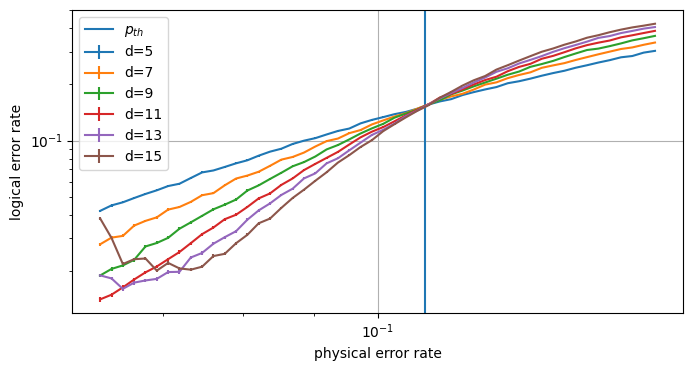

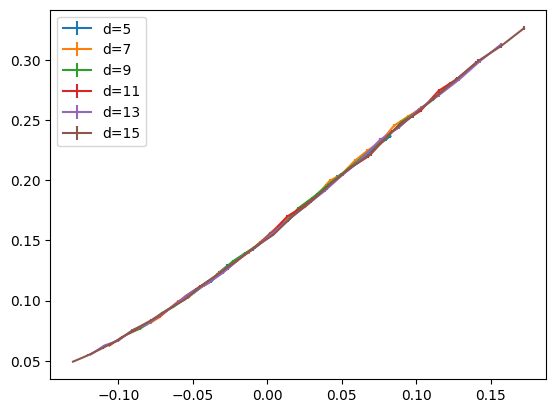

<Figure size 640x480 with 0 Axes>

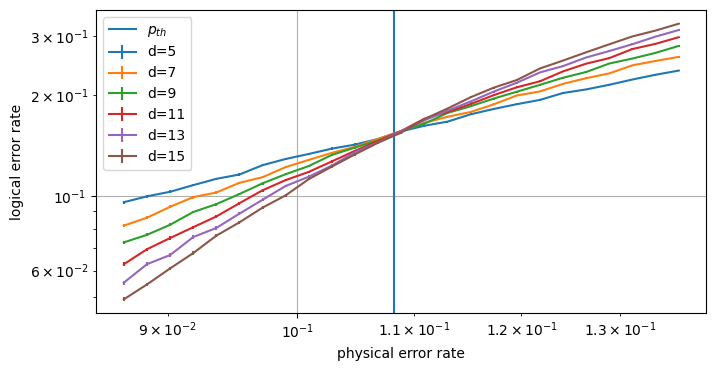

[0.10818702]
[1.49589616]


In [14]:
folder_name = folder_name_ML_Z
p_window = 10**(0.1) 
min_distance = 5 

g_pth = 0.1085
g_nu = 1.5

result = analysis_pipeline(
    folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth / p_window,
    max_noise_rate = g_pth * p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9376233363420663
             x: [ 1.074e-01  6.580e-01]
           nit: 44
          nfev: 86
 final_simplex: (array([[ 1.074e-01,  6.580e-01],
                       [ 1.074e-01,  6.580e-01],
                       [ 1.074e-01,  6.580e-01]]), array([ 9.376e-01,  9.376e-01,  9.376e-01]))
[0.10744564]
[0.00346944]


<Figure size 640x480 with 0 Axes>

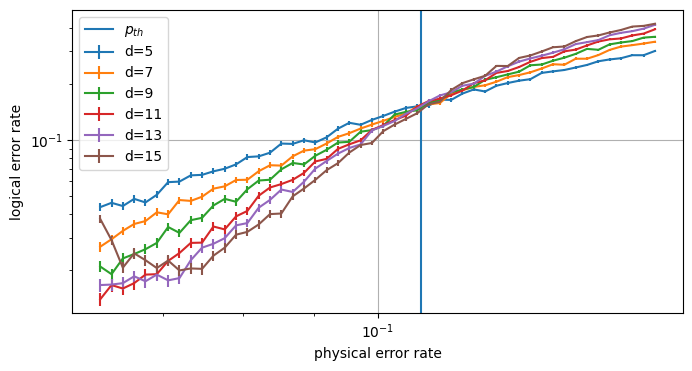

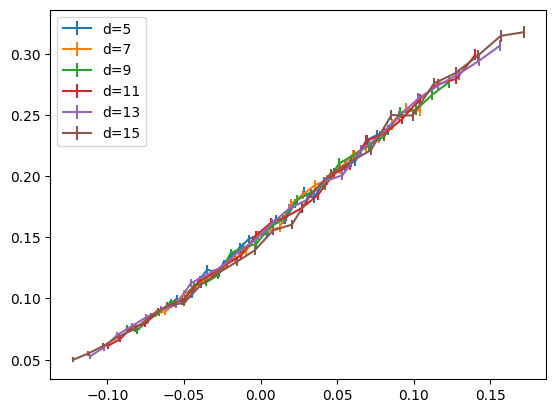

<Figure size 640x480 with 0 Axes>

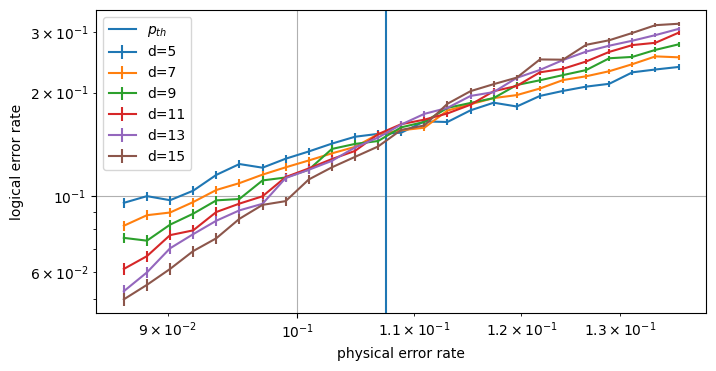

[0.10744564]
[1.51965649]


In [15]:
folder_name = folder_name_ML_X 
p_window = 10**(0.1) 
min_distance = 5

g_pth = 0.1085
g_nu = 1.5

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth / p_window,
    max_noise_rate = g_pth * p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.152797333030551
             x: [ 1.025e-01  6.738e-01]
           nit: 30
          nfev: 62
 final_simplex: (array([[ 1.025e-01,  6.738e-01],
                       [ 1.025e-01,  6.738e-01],
                       [ 1.025e-01,  6.738e-01]]), array([ 1.153e+00,  1.153e+00,  1.153e+00]))
[0.10253642]
[0.00084491]


<Figure size 640x480 with 0 Axes>

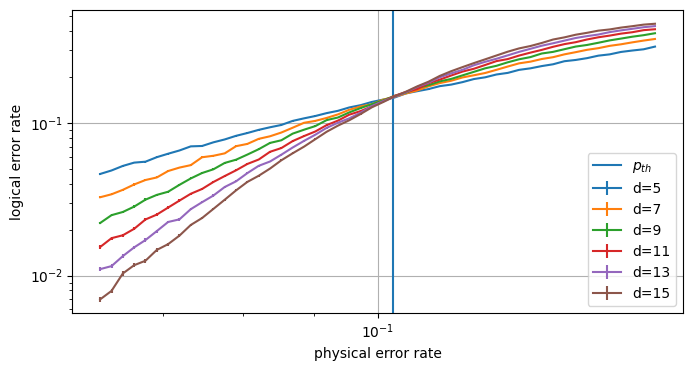

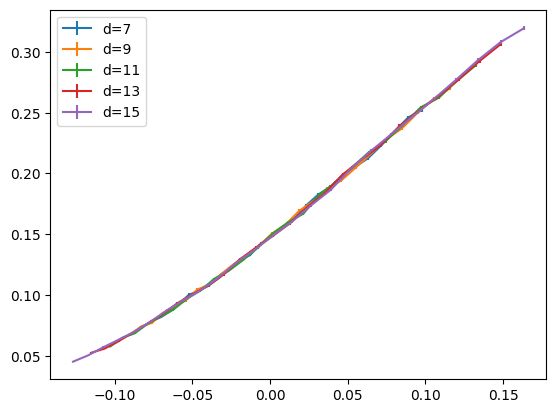

<Figure size 640x480 with 0 Axes>

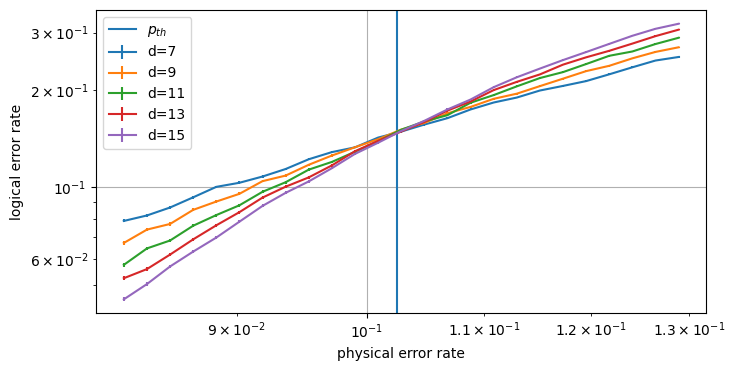

[0.10253642]
[1.48413436]


In [16]:
folder_name = folder_name_MWPM_Z 
p_window = 10**(0.1) 
min_distance = 7

g_pth = 0.103
g_nu = 1.5

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth / p_window,
    max_noise_rate = g_pth * p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.0163439050374619
             x: [ 1.032e-01  6.773e-01]
           nit: 43
          nfev: 88
 final_simplex: (array([[ 1.032e-01,  6.773e-01],
                       [ 1.032e-01,  6.772e-01],
                       [ 1.032e-01,  6.772e-01]]), array([ 1.016e+00,  1.016e+00,  1.016e+00]))
[0.10315292]
[0.00074301]


<Figure size 640x480 with 0 Axes>

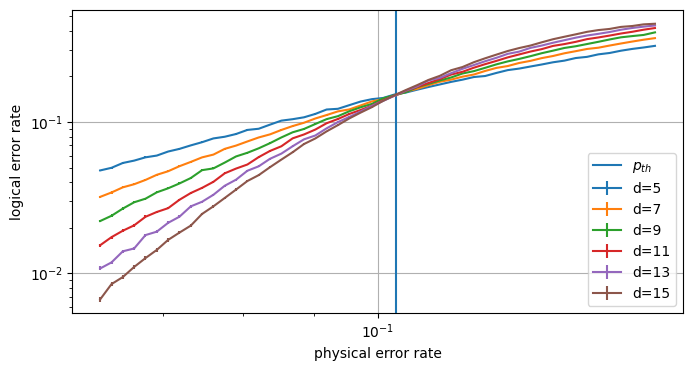

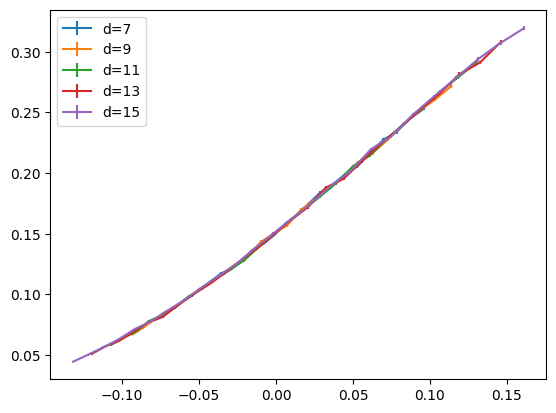

<Figure size 640x480 with 0 Axes>

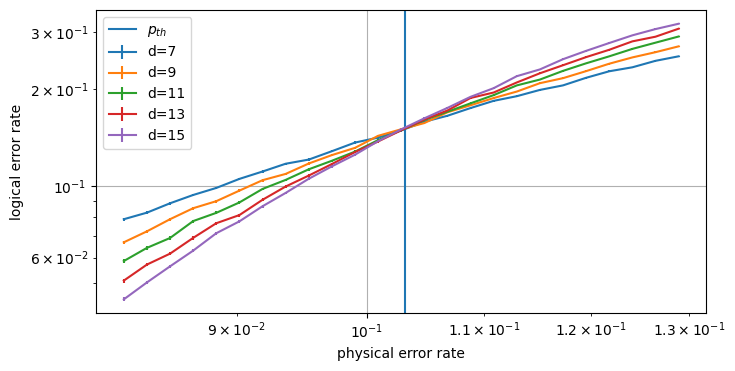

[0.10315292]
[1.47655689]


In [17]:
folder_name = folder_name_MWPM_X 
p_window = 10**(0.1) 
min_distance = 7

g_pth = 0.103
g_nu = 1.5

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth / p_window,
    max_noise_rate = g_pth * p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

## Thresholds Results

In [18]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]
literature = [0.109, 0.109, 0.103, 0.103]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f}% (literatur: {literature[i]*10**2:.3f}%)")



For ML Z: threshold = 10.819% (literatur: 10.900%)
For ML X: threshold = 10.745% (literatur: 10.900%)
For MWPM Z: threshold = 10.254% (literatur: 10.300%)
For MWPM X: threshold = 10.315% (literatur: 10.300%)


## Varying parameters

In [19]:
# Data sources
folder_name_ML_Z = "basic_md_1r_steane_Z_ML_lots"
folder_name_ML_X = "basic_md_1r_steane_X_ML"
folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"
folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

# as collections
folder_names = [folder_name_ML_Z, folder_name_ML_X, folder_name_MWPM_Z, folder_name_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pth_ml = 0.109
g_pth_mwpm = 0.103
g_pths = [g_pth_ml, g_pth_ml, g_pth_mwpm, g_pth_mwpm]

g_nu = 1.5
g_nus = [g_nu] * 4

In [20]:
min_distances = [5,7,9,11,13]
p_window = 10**(0.1) 

p_th_varied = np.zeros((len(min_distances), len(folder_names)))
err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 

for j in range(len(min_distances)):
    for i in range(len(folder_names)):
        result = analysis_pipeline(
            folder_name = folder_names[i],
            guess_pth = [g_pths[i]],
            guess_nu = [g_nus[i]],
            min_distance= min_distances[j], 
            min_noise_rate = g_pths[i] / p_window,
            max_noise_rate = g_pths[i] * p_window,
            plots=False
            )

        p_th_varied[j,i] =  result["p_th"][0]
        err_p_th_varied[j,i] =  result["err_p_th"][0]
        nu_fit_varied[j,i] = result["nu_fit"][0]


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9282705815882332
             x: [ 1.082e-01  6.701e-01]
           nit: 59
          nfev: 115
 final_simplex: (array([[ 1.082e-01,  6.701e-01],
                       [ 1.082e-01,  6.701e-01],
                       [ 1.082e-01,  6.701e-01]]), array([ 9.283e-01,  9.283e-01,  9.283e-01]))
[0.10815531]
[0.0008853]

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9328527915143268
             x: [ 1.091e-01  7.015e-01]
           nit: 54
          nfev: 116
 final_simplex: (array([[ 1.091e-01,  7.015e-01],
                       [ 1.091e-01,  7.015e-01],
                       [ 1.091e-01,  7.015e-01]]), array([ 9.329e-01,  9.329e-01,  9.329e-01]))
[0.10905302]
[0.00343508]

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1842023413957243
             x

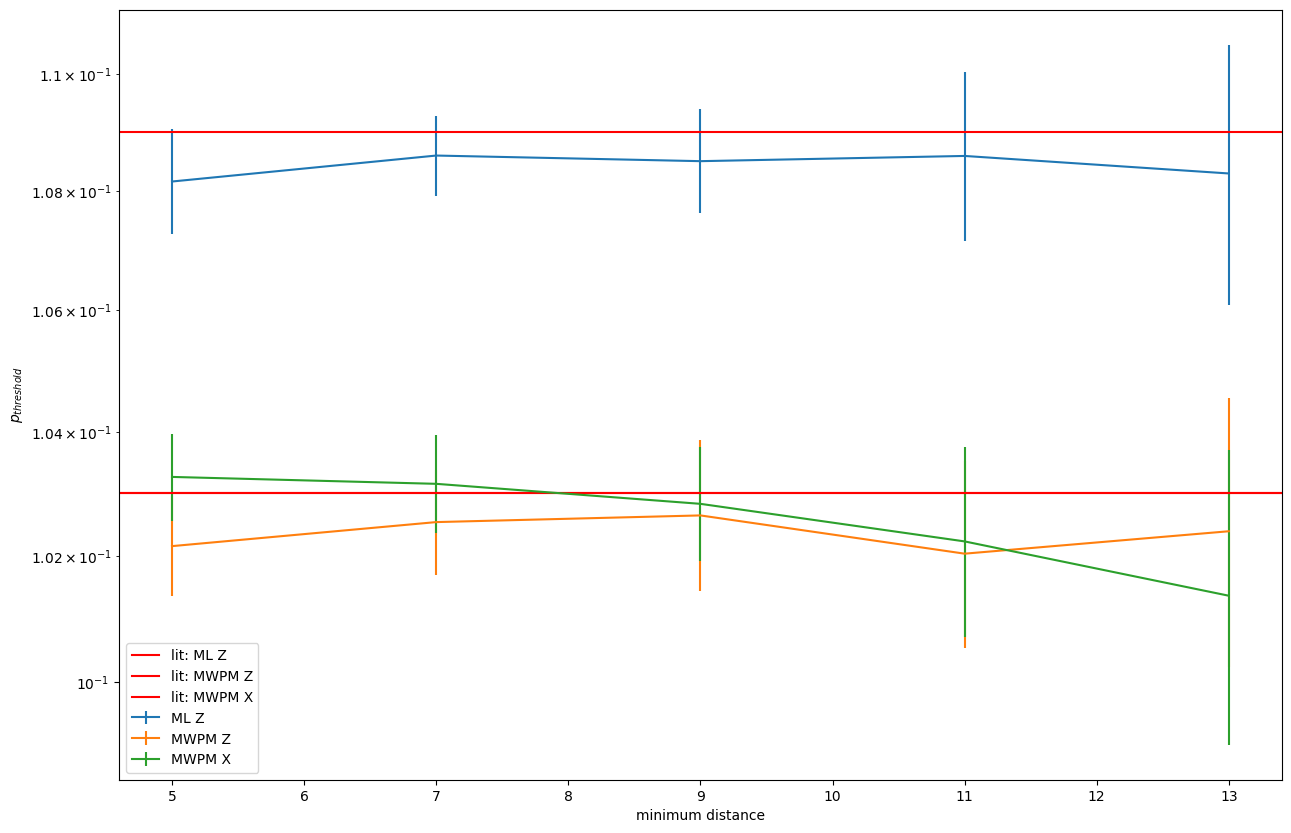

In [22]:
literature = [0.109, 0.109, 0.103, 0.103]
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    if i == 1:
        pass
        continue
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
    plt.axhline(literature[i], label="lit: "+ names[i], color= "red" )
plt.ylabel("$p_{threshold}$")
plt.yscale("log")
plt.legend()
plt.show()